In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent   # car notebook est dans notebook/ et pas dans le root du projet
sys.path.insert(0, str(PROJECT_ROOT))

# Carte émission de CO2 par habitant en europe (2021)

📊 Centrage intelligent appliqué:
   Format: Personnalisé (N/A)
   Ratio figure: 1.00
   Ratio données: 1.20
   Étendue: [-61.15, 46.70, -12.57, 95.28]
🖼️ Image ajoutée
📊 Centrage intelligent appliqué:
   Format: Personnalisé (N/A)
   Ratio figure: 1.00
   Ratio données: 1.27
   Étendue: [-14.64, 44.64, 22.86, 82.14]


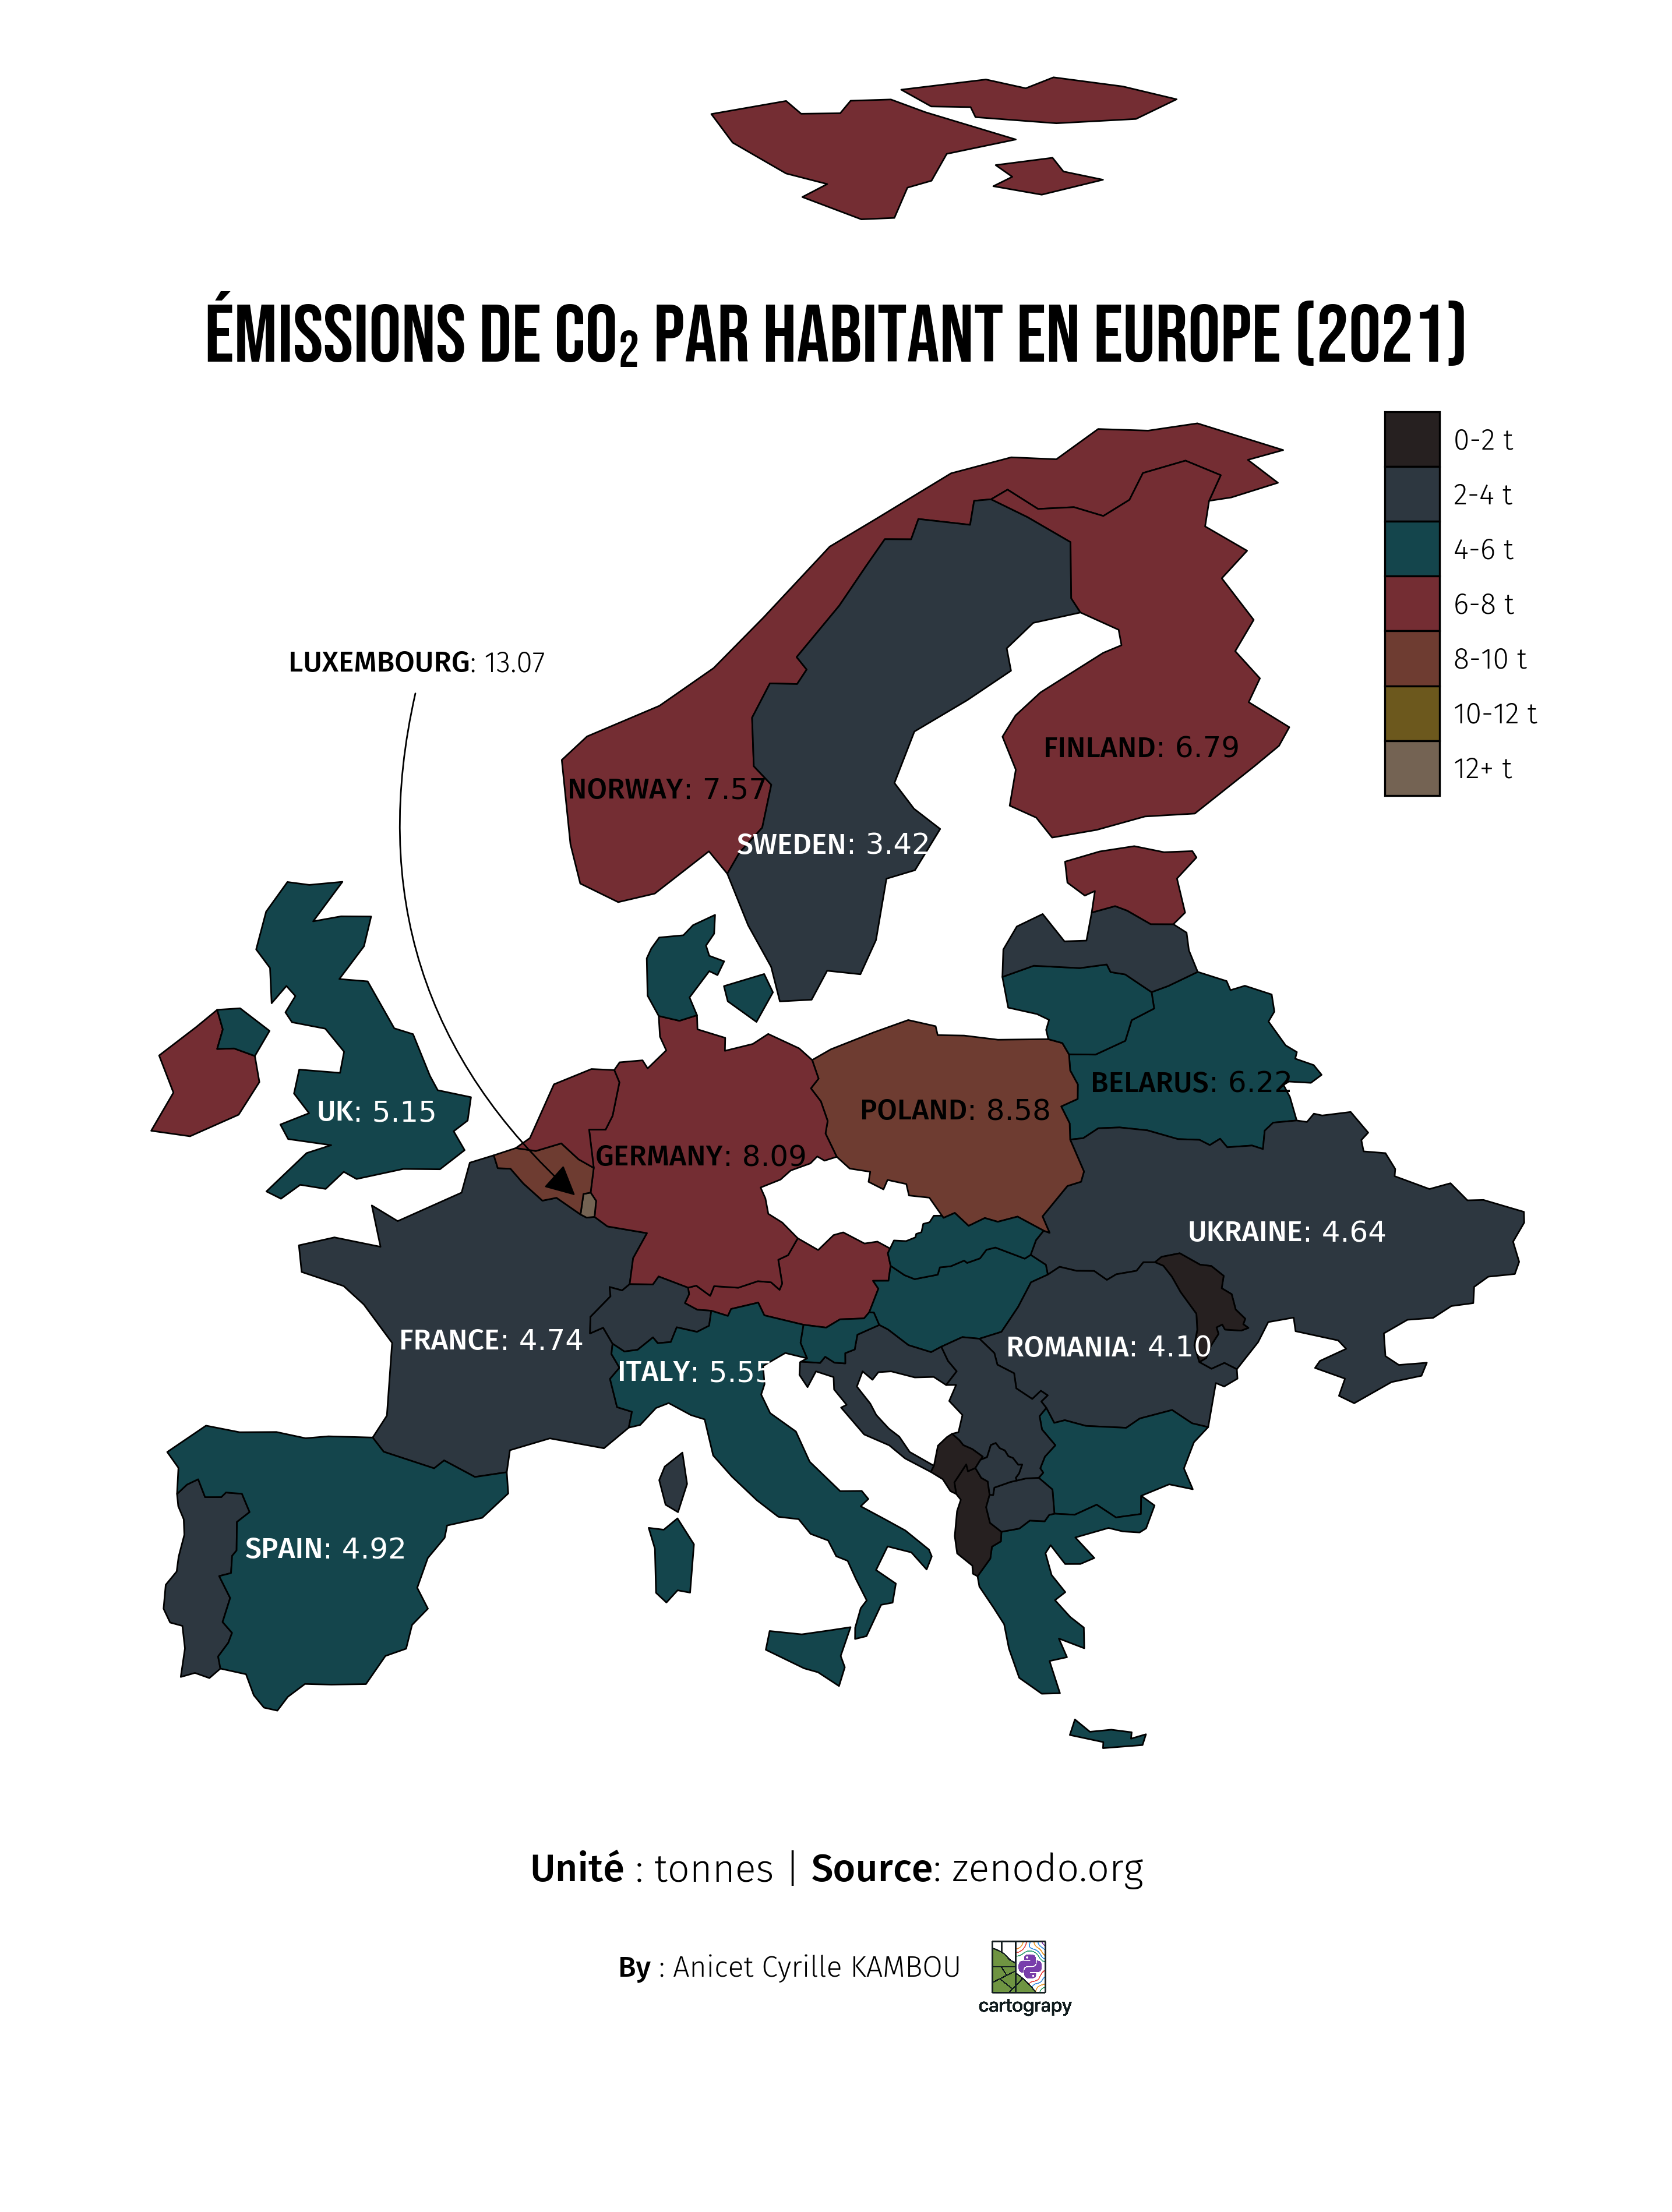

In [10]:
import pandas as pd
import cartograpy as cp

# 1. DONNÉES
world = cp.load(
    "https://raw.githubusercontent.com/holtzy/the-python-graph-gallery/master/static/data/europe.geojson"
)
df = cp.load(
    "https://raw.githubusercontent.com/holtzy/the-python-graph-gallery/master/static/data/co2PerCapita.csv"
)

df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df["Total"] = pd.to_numeric(df["Total"], errors="coerce")

## Fusion des données
data = world.merge(df, how="left", left_on="name", right_on="Country")

## Filtrage des données pour l'Europe, en excluant la Russie et l'Islande, et en ne gardant que l'année 2021
data = data.query('continent == "Europe" and name not in ["Russia", "Iceland"] and Year == 2021')
data = data[["name", "Total", "geometry"]].dropna(subset=["Total", "geometry"]).copy()

proj = data.to_crs(epsg=3035)
data["centroid"] = proj.geometry.centroid.to_crs(data.crs)

my_cmap = "PonyoDark"
# 2. POLICES
font_title = cp.google_font("Bebas Neue")
font_text = cp.google_font("Fira Sans", weight="light")
font_bold = cp.google_font("Fira Sans", weight="medium")

text_color = "black"
background_color = "white"

# 3. CARTE
m = cp.Map(figsize=(10, 10), dpi=400, basemap=False, title="")
m.set_background_color(background_color)
m.add_polygons_choropleth(
    data,
    column_to_plot="Total",
    cmap=my_cmap,
    edge_color="black",
    linewidth=0.5,
    show_labels=True,
    show_colorbar=False,
)
m.set_extent([-11, 32, 41, 73])
m.hide_gridline()
# m.add_basemap()

# 4. ANNOTATIONS PAR PAYS (nom en gras inline via add_custom_text)
adjustments = {
    "France": (10, 3), "Italy": (-2.4, 2.5), "Finland": (0, -2),
    "Belarus": (0, -0.4), "Ireland": (0, -1), "Germany": (-0.2, 0),
    "Poland": (0, 0.2), "Sweden": (-1.2, -2.8),
    "United Kingdom": (1, -1.5), "Norway": (-4, -5.5),
}
countries_to_annotate = [
    "France", "Italy", "Romania", "Poland", "Finland", "Ukraine",
    "Spain", "Germany", "Sweden", "United Kingdom", "Belarus", "Norway",
]

data_by_country = data.set_index("name")

for country in countries_to_annotate:
    if country not in data_by_country.index:
        continue
    row = data_by_country.loc[country]
    dx, dy = adjustments.get(country, (0, 0))
    x, y = row["centroid"].x + dx, row["centroid"].y + dy
    rate = row["Total"]
    label = "UK" if country == "United Kingdom" else country

    m.add_custom_text(
        f"<{label.upper()}>: {rate:.2f}", (x, y), to="ax",
        fontsize=9, color="white" if rate < 6 else text_color,
        ha="center", va="center",
        highlight_textprops=[{"font": font_bold}],
    )


# 5. LUXEMBOURG (add_fig_arrow + add_custom_text, en coords figure 0-1)
lux = data[data["name"] == "Luxembourg"]
if not lux.empty:
    lux_value = lux.iloc[0]["Total"]

    m.add_fig_arrow(
        tail_position=(0.32, 0.70),
        head_position=(0.39, 0.48),
        radius=0.3,
        width=0.5, head_width=4, head_length=8, color="black",
    )
    m.add_custom_text(
        f"<LUXEMBOURG>: {lux_value:.2f}", (0.32, 0.71), to="fig",
        highlight_textprops=[{"font": font_bold}],
        color=text_color, fontsize=9, font=font_text,
        ha="center", va="center",
    )

# 6. LÉGENDE PAR CLASSES
value_ranges = [0, 2, 4, 6, 8, 10, 12, 15]
labels = ["0-2 t", "2-4 t", "4-6 t", "6-8 t", "8-10 t", "10-12 t", "12+ t"]
cmap_obj = cp.load_cmap(my_cmap)

items = [
    (lab, cmap_obj((value_ranges[i] + value_ranges[i + 1]) / 2 / value_ranges[-1]))
    for i, lab in enumerate(labels)
]
m.add_swatch_legend(
    items, xy=(35, 70),
    rect_width=2, 
    rect_height=1.5, y_step=1.5,
    fontsize=9, color=text_color,
    edge_color="black", linewidth=0.6,
    font=font_text,
)

# 7. TITRE / SOUS-TITRE
m.add_custom_text(
    "Émissions de CO₂ par habitant en Europe (2021)", (0.5, 0.87), to="fig",
    color=text_color, fontsize=25, font=font_title,
    ha="center", va="top",
)
m.add_custom_text(
    "<Unité> : tonnes | <Source>: zenodo.org", (0.5, 0.2), to="fig",
    color=text_color, fontsize=12, font=font_text,
    ha="center", va="top",
    highlight_textprops=[{"font": font_bold}, {"font": font_bold}],
)

m.add_custom_text(
    "<By> : Anicet Cyrille KAMBOU", (0.48, 0.15), to="fig",
    color=text_color, fontsize=9, font=font_text,
    ha="center", va="center",
    highlight_textprops=[{"font": font_bold}],
)

# m.add_north_arrow(to="fig", shadow=False,scale=0.3, label=" ",position=(0.3, 0.85))

m.add_image("logo.png", (0.44, 0.1), zoom=0.035) 

# m.add_background_image("bg_image.jpg", alpha=0.5, zoom=1)
# 8. EXPORT
# m.save("output_galerie/web-map-with-custom-legend.png", dpi=600)
m.show()

# Carte des régions de la Côte d'Ivoire

⚠️  Attention: Aucun CRS défini. Attribution du CRS par défaut: EPSG:4326
🧭 Flèche du Nord ajoutée (map-utils)


📊 Centrage intelligent appliqué:
   Format: Personnalisé (N/A)
   Ratio figure: 1.50
   Ratio données: 0.96
   Étendue: [-11.02, -0.11, 3.90, 11.17]


C:\Users\Ordinateur\OneDrive\cartograpy\cartograpy\mapper\map.py:974: UserWarning: Aucun CRS défini. Attribution du CRS par défaut: EPSG:4326
  return self._add_gdf_layer(
c:\Users\Ordinateur\OneDrive\cartograpy\.venv\Lib\site-packages\matplotlib_map_utils\core\scale_bar.py:781: UserWarning: Provided CRS EPSG:4326 uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.
  warnings.warn(f"Provided CRS {bar_projection} uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.")
c:\Users\Ordinateur\OneDrive\cartograpy\.venv\Lib\site-packages\matplotlib_map_utils\core\scale_bar.py:781: UserWarning: Provided CRS EPSG:4326 uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.
  warnings.warn(f"Provided CRS {bar_projection} uses degre

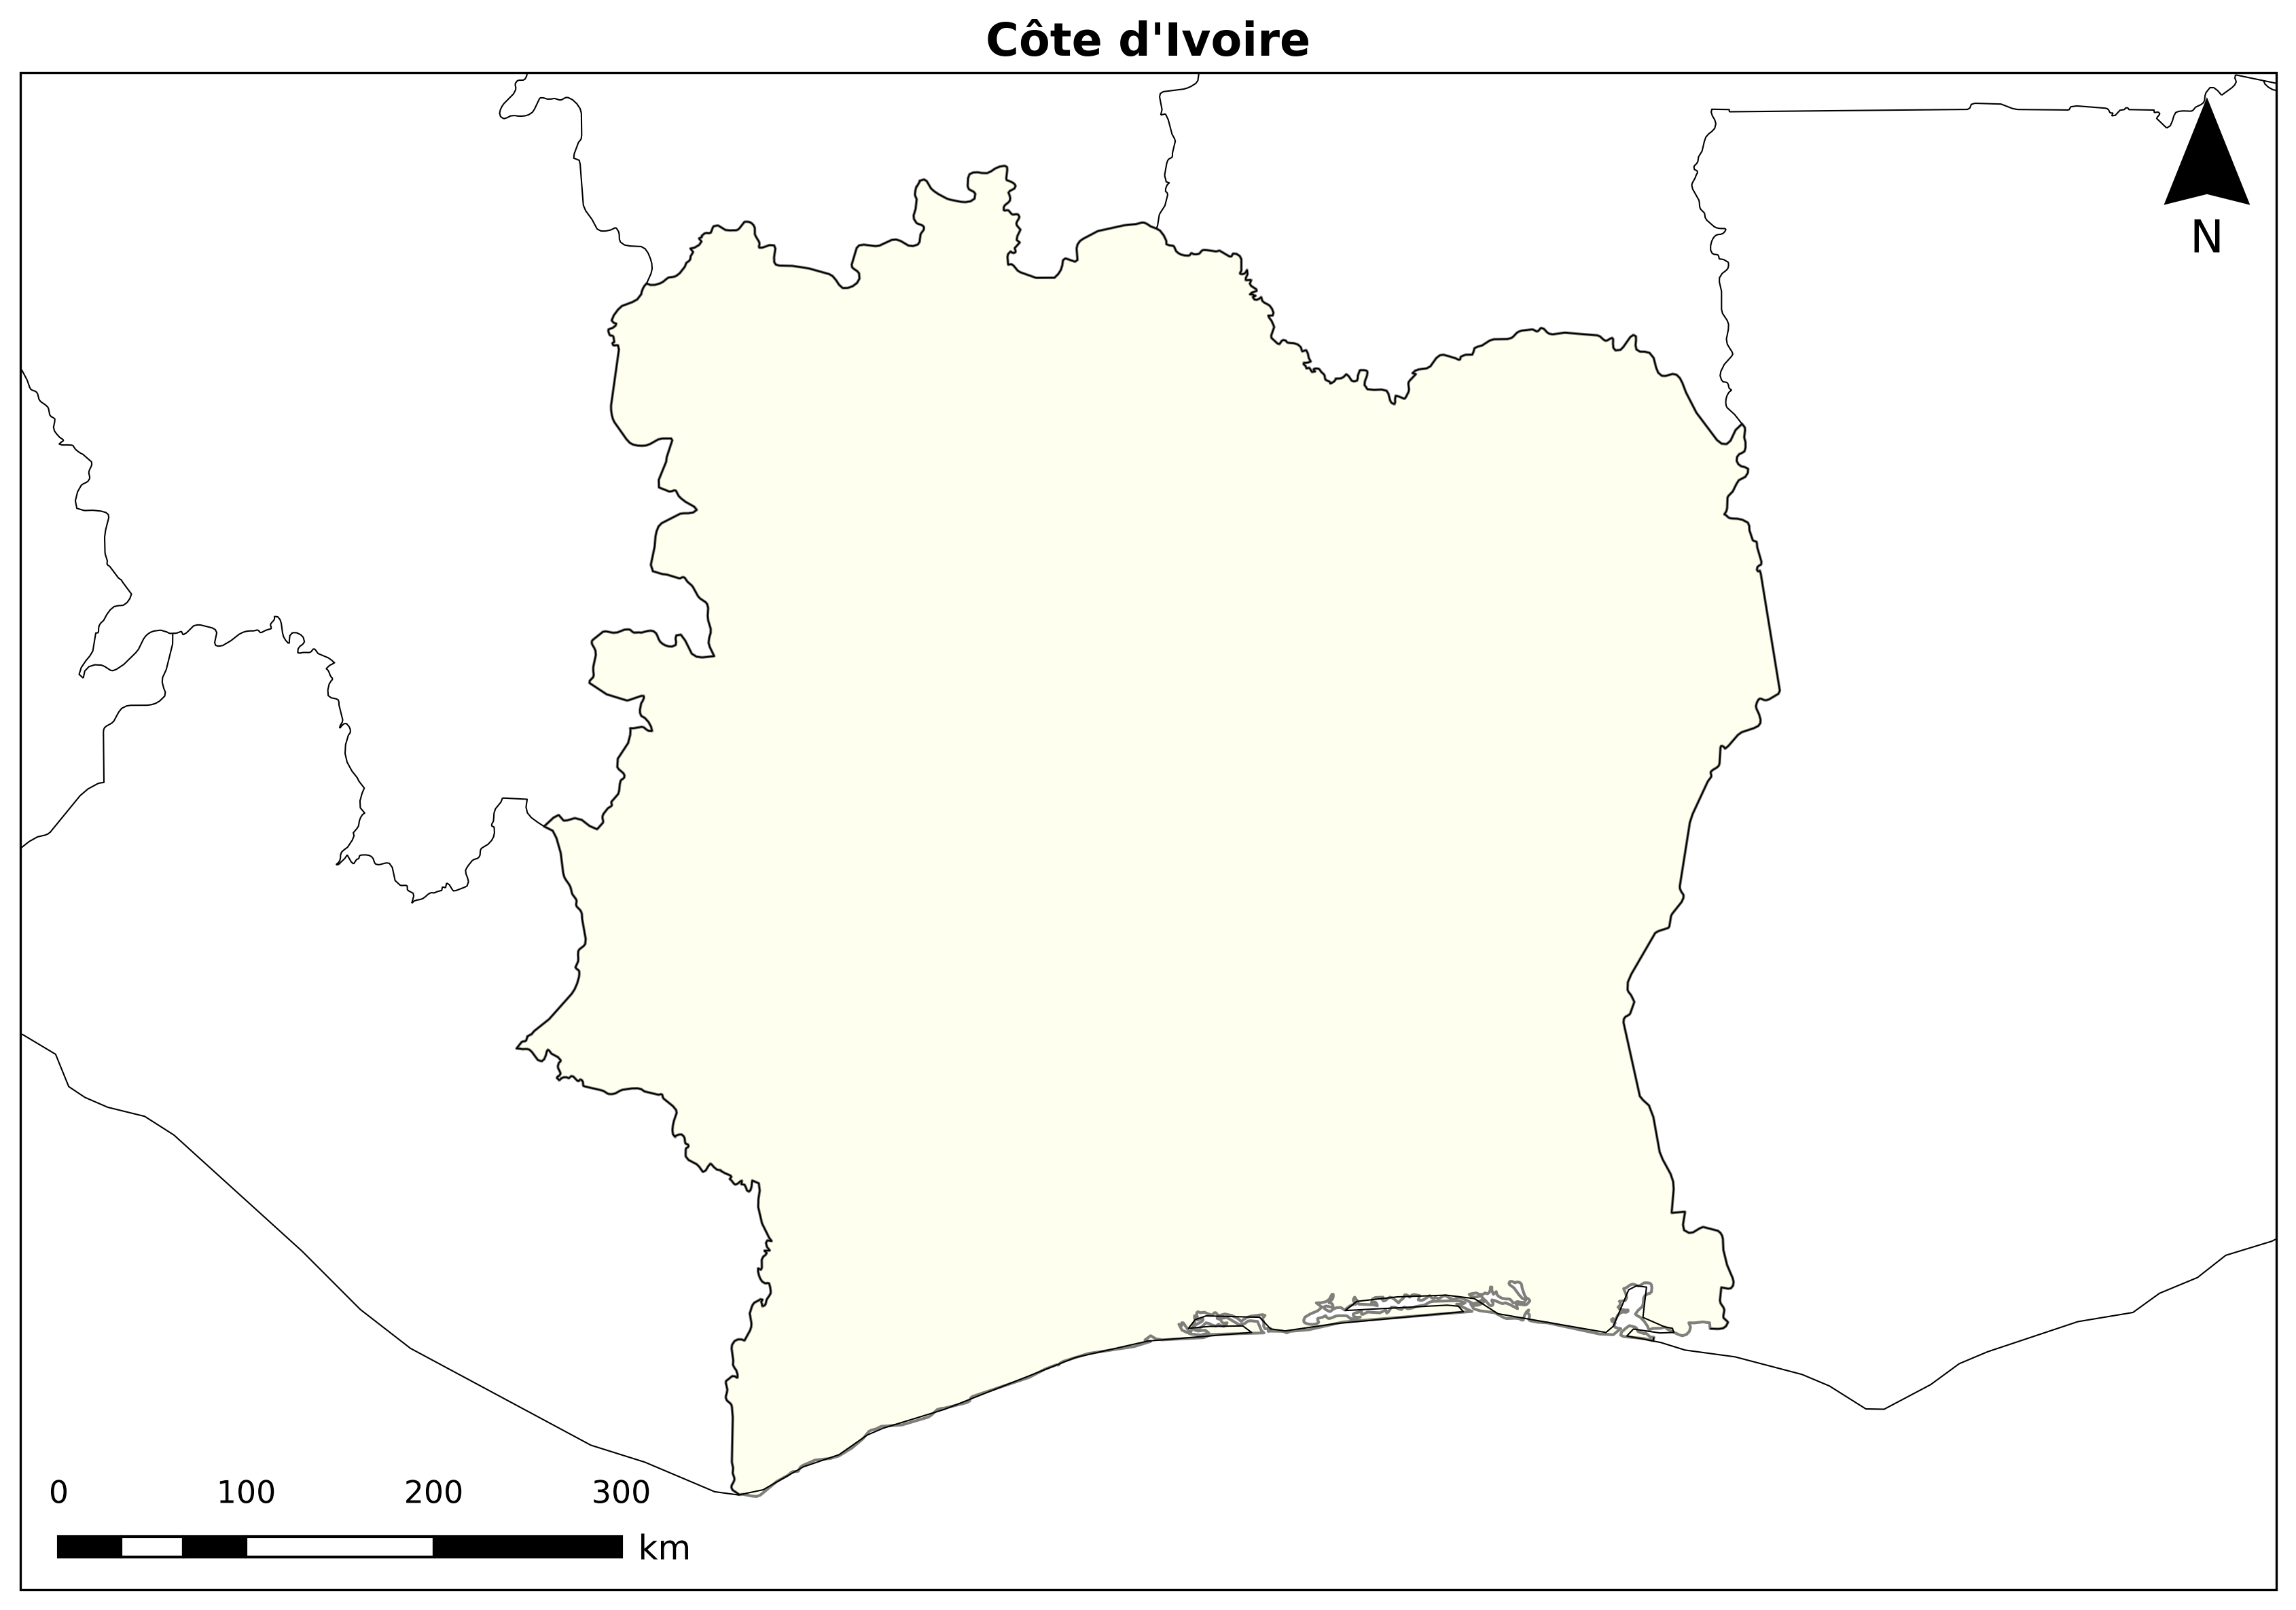

In [24]:
from cartograpy.data import Bound
from cartograpy.mapper import Map

bound = Bound()
civ = bound.get_admin("CIV", adm=0)  # frontières nationales, via GeoBoundaries

m = Map(title="Côte d'Ivoire")
m.add_polygons(civ, facecolor="lightyellow", edgecolor="black")
m.add_north_arrow()
m.add_scale_bar()
m.show()

C:\Users\Ordinateur\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\importlib\metadata\__init__.py:467: DeprecationWarning: Implicit None on return values is deprecated and will raise KeyErrors.
  return self.metadata['Version']


⚠️  Attention: Aucun CRS défini. Attribution du CRS par défaut: EPSG:4326


C:\Users\Ordinateur\AppData\Local\Temp\ipykernel_28660\295906499.py:18: UserWarning: Aucun CRS défini. Attribution du CRS par défaut: EPSG:4326
  m.add_layer(civ, facecolor="lightyellow", edgecolor="black")
c:\Users\Ordinateur\OneDrive\cartograpy\cartograpy\mapper\map.py:3094: DeprecationWarning: pathlib.Path.__enter__() is deprecated and scheduled for removal in Python 3.13; Path objects as a context manager is a no-op
  with importlib.resources.files("cartograpy").joinpath(
Can't handle color: param(outline)
Can't handle color: param(outline)
Can't handle color: param(outline)
Can't handle color: param(outline)
Can't handle color: param(outline)
Can't handle color: param(outline)
Can't handle color: param(outline)
Can't handle color: param(outline)
Can't handle color: param(outline)
Can't handle color: param(outline)
Can't handle color: param(outline)
Can't handle color: param(outline)
Can't handle color: param(outline)
Can't handle color: param(outline)
Can't handle color: param(out

🧭 Flèche du Nord ajoutée (SVG)
🔍 Carte de situation ajoutée (map-utils)
📊 Centrage intelligent appliqué:
   Format: Personnalisé (N/A)
   Ratio figure: 1.50
   Ratio données: 0.95
   Étendue: [-11.00, -0.08, 3.91, 11.19]


c:\Users\Ordinateur\OneDrive\cartograpy\cartograpy\mapper\map.py:5391: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self.fig.tight_layout()
c:\Users\Ordinateur\OneDrive\cartograpy\.venv\Lib\site-packages\matplotlib_map_utils\core\scale_bar.py:781: UserWarning: Provided CRS EPSG:4326 uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.
  warnings.warn(f"Provided CRS {bar_projection} uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.")
c:\Users\Ordinateur\OneDrive\cartograpy\.venv\Lib\site-packages\matplotlib_map_utils\core\scale_bar.py:781: UserWarning: Provided CRS EPSG:4326 uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.
  warnings.warn(f"Pr

Carte sauvegardée: output_galerie/carte_regions_cote_d_ivoire.png


c:\Users\Ordinateur\OneDrive\cartograpy\.venv\Lib\site-packages\matplotlib_map_utils\core\scale_bar.py:781: UserWarning: Provided CRS EPSG:4326 uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.
  warnings.warn(f"Provided CRS {bar_projection} uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.")
c:\Users\Ordinateur\OneDrive\cartograpy\.venv\Lib\site-packages\matplotlib_map_utils\core\scale_bar.py:781: UserWarning: Provided CRS EPSG:4326 uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.
  warnings.warn(f"Provided CRS {bar_projection} uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.")
c:\Users\Ordinateur\OneDrive\cartogr

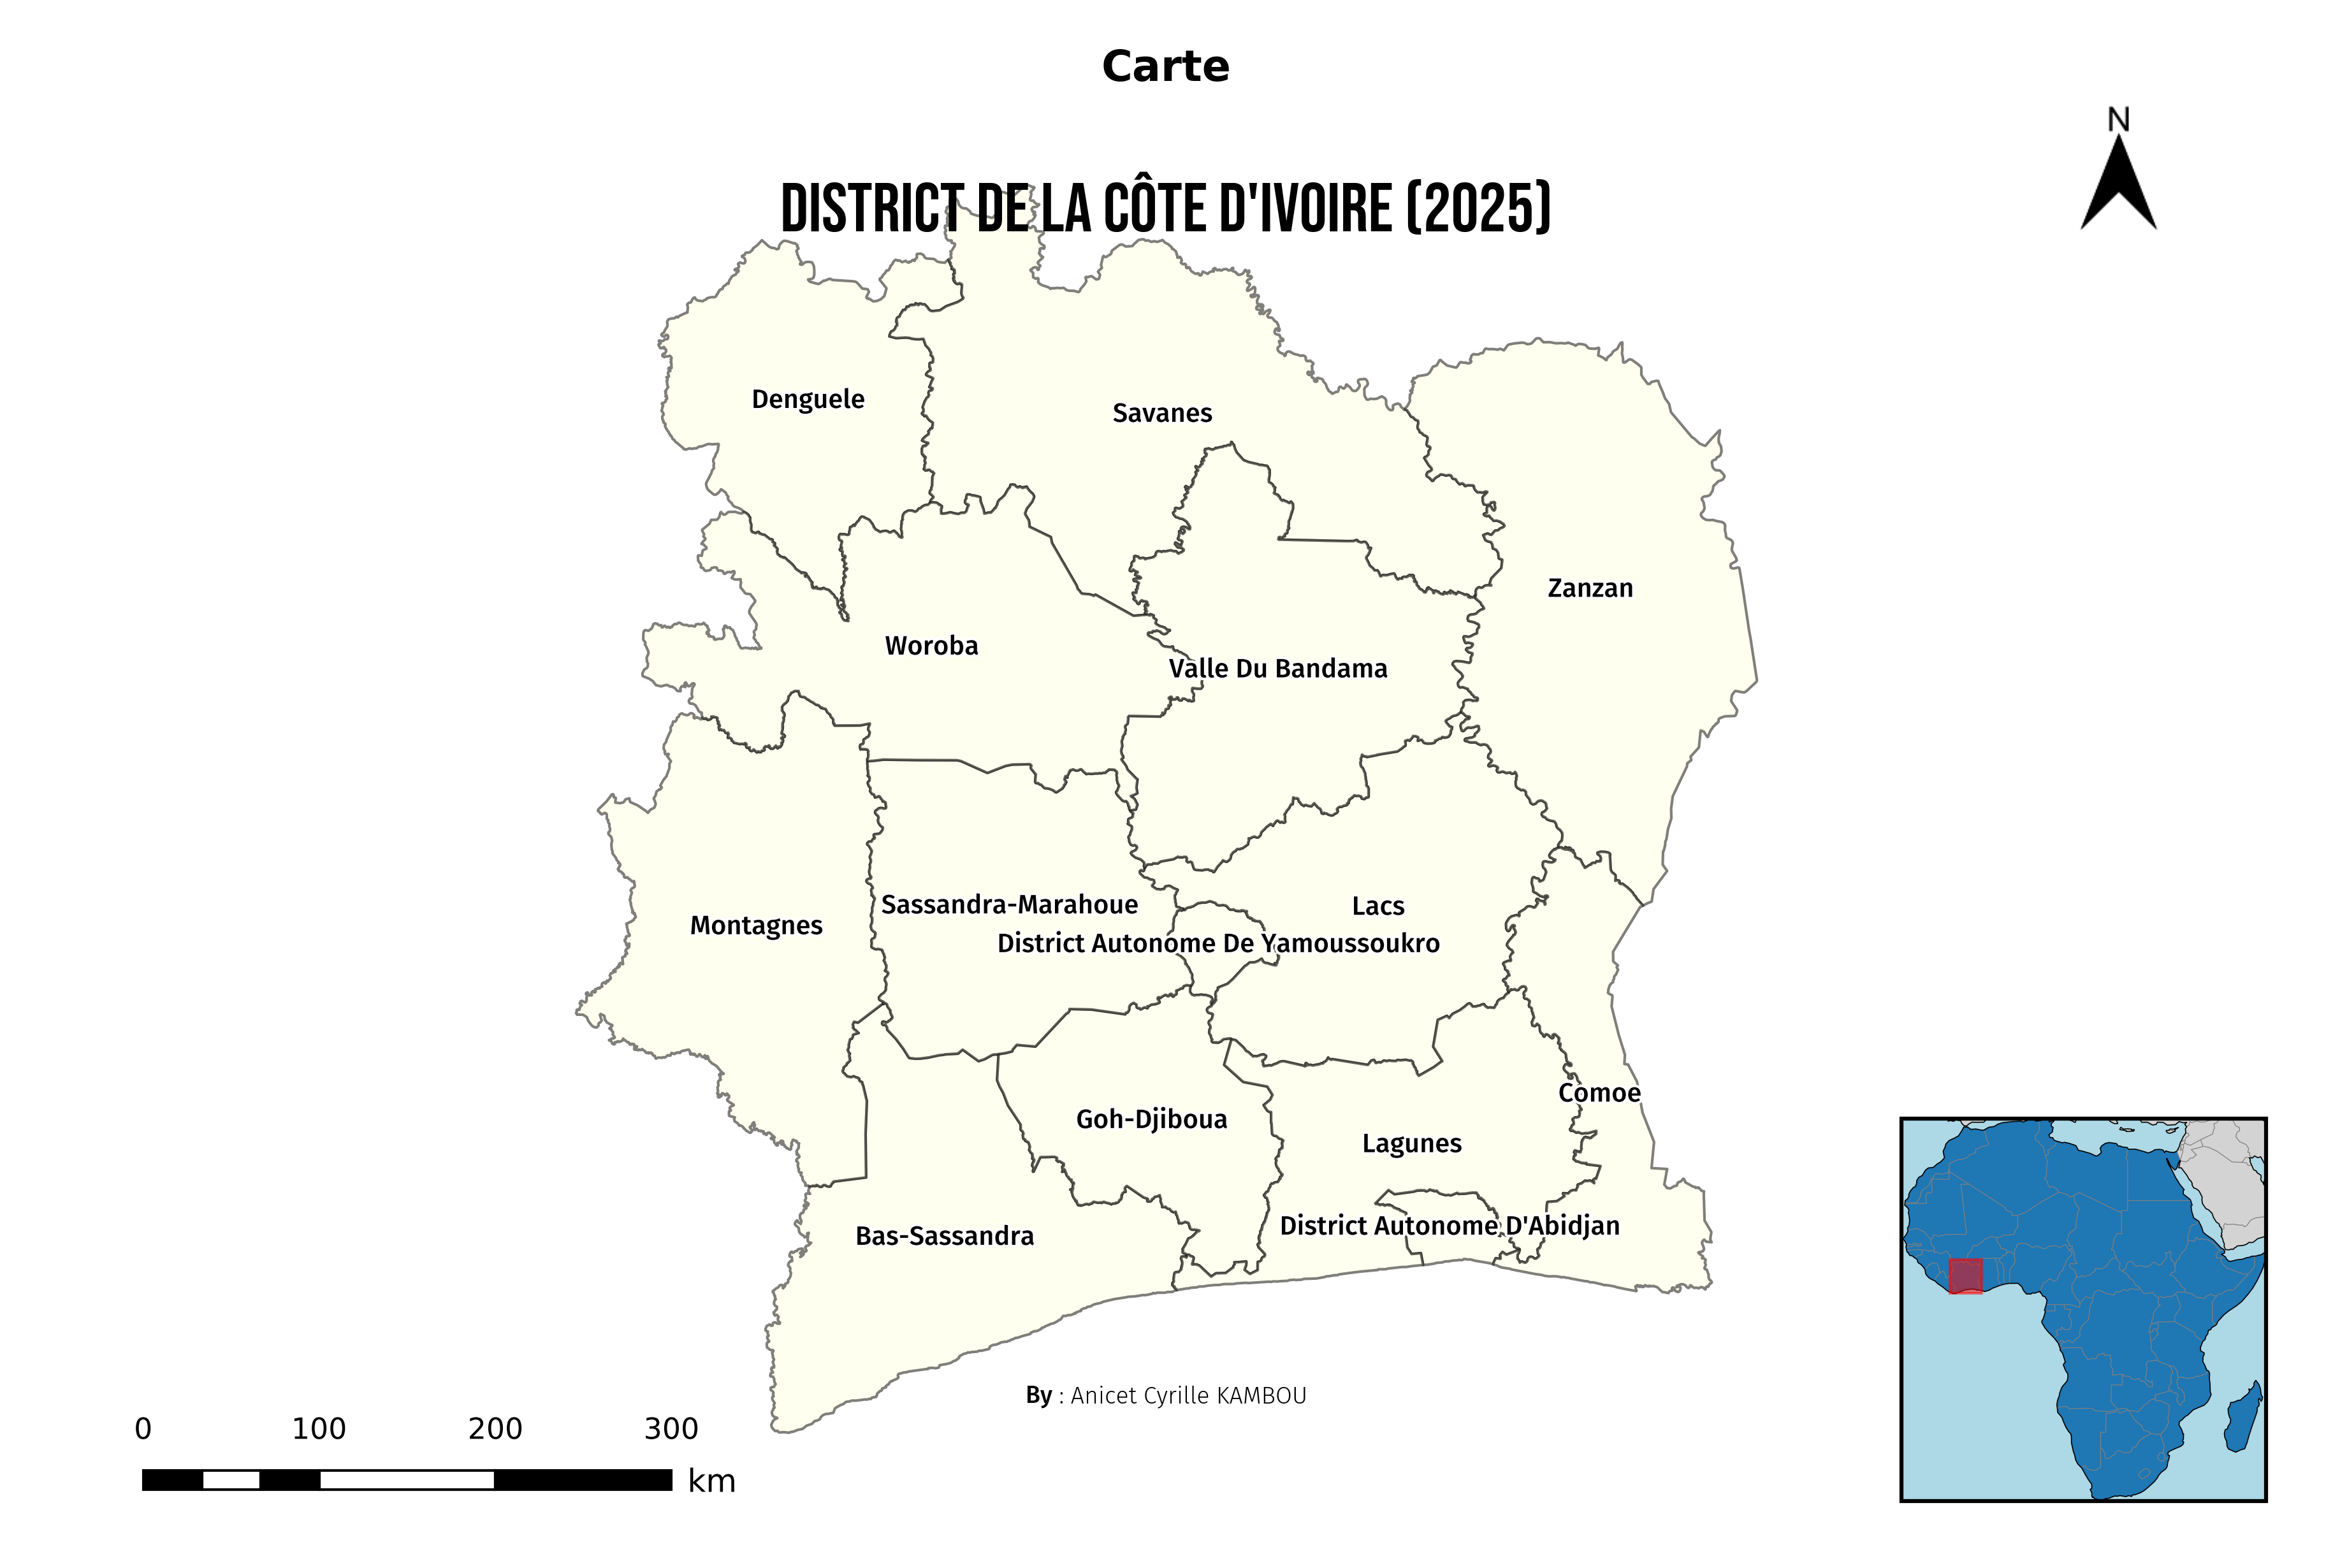

In [2]:
import cartograpy as cp
from cartograpy.data import Bound
from cartograpy.mapper import Map


my_cmap = "PonyoDark"
# 2. POLICES
font_title = cp.google_font("Bebas Neue")
font_text = cp.google_font("Fira Sans", weight="light")
font_bold = cp.google_font("Fira Sans", weight="medium")
font = cp.google_font("Fira Sans", weight="medium")

bound = Bound()
civ = bound.get_admin("CIV", adm=1)  # frontières nationales, via GeoBoundaries

m = Map(basemap=False)

m.add_layer(civ, facecolor="lightyellow", edgecolor="black")
m.add_north_arrow(style="svg",arrow=10, zoom=0.4, color="black")
# m.add_gridlines()
m.hide_gridline()
m.set_background_color("white")
m.add_scale_bar()
m.add_labels(civ, label_column="shapeName",font=font,color="black")
m.add_inset(data=civ, on=bound.get_continent("Africa"),zoom_to_on=True,box_color="black",box_linewidth=1,to="fig")
m.add_custom_text(
    "District de la Côte d'Ivoire (2025)", (0.5, 0.90), to="fig",
    color="black", fontsize=26, font=font_title,
    ha="center", va="top",
)
m.add_custom_text(
    "<By> : Anicet Cyrille KAMBOU", (0.50, 0.1), to="fig",
    color="black", fontsize=9, font=font_text,
    ha="center", va="center",
    highlight_textprops=[{"font": font_bold}],
)

m.save("output_galerie/carte_regions_cote_d_ivoire.png", dpi=300)